# COD  RESTful API  #
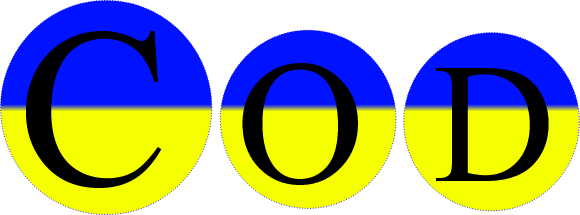


**Help**

https://wiki.crystallography.net/RESTful_API/?

In [1]:
import requests

cod_id = "9000137"
url = f"https://www.crystallography.net/cod/{cod_id}.cif"

cif_text = requests.get(url).text

with open(f"{cod_id}.cif", "w") as f:
    f.write(cif_text)

In [12]:
url = "https://www.crystallography.net/cod/result"

params = {
    "el1": "Sn",
    "el2": "Cr",
    "el3": "S",
    "format": "json"
}

data = requests.get(url, params=params).json()

for e in data[:10]:
    print(e["file"])
print('='*20)
for key, value in data[0].items():
    print(key, ' =' ,value)

1008302
1509266
1509268
1509269
1509270
1509982
1509983
1535572
1535575
1535583
file  = 1008302
a  = 10.101
siga  = 0.002
b  = 10.101
sigb  = 0.002
c  = 10.101
sigc  = 0.002
alpha  = 90
sigalpha  = None
beta  = 90
sigbeta  = None
gamma  = 90
siggamma  = None
vol  = 1030.6
sigvol  = None
celltemp  = None
sigcelltemp  = None
diffrtemp  = None
sigdiffrtemp  = None
cellpressure  = None
sigcellpressure  = None
diffrpressure  = None
sigdiffrpressure  = None
thermalhist  = None
pressurehist  = None
compoundsource  = None
nel  = 4
sg  = F d -3 m :1
sgHall  = F 4d 2 3 -1d
sgNumber  = 227
commonname  = None
chemname  = Copper chromium tin sulfide (1.10/1.30/0.70/3.90)
mineral  = None
formula  = - Cr1.3 Cu1.1 S3.9 Sn0.7 -
calcformula  = - Cr1.3 Cu1.1 S3.9 Sn0.7 -
cellformula  = - Cr10.4 Cu8.8 S31.2 Sn5.6 -
Z  = 8
Zprime  = 0.0416667
acce_code  = None
authors  = Danot, M; Colombet, P; Tremblet, M; Soubeyroux, J L
title  = Crystal Structure of a Metal Excess Spinel: Cu~1.10~ Cr~1.30~ Sn~0.70~ S~3.9

In [58]:
# COD RESTful API - Comprehensive Examples
import requests
import json
from typing import List, Dict, Optional, Tuple
import pandas as pd


# ============================================
# SECTION 1: BASIC CIF FILE RETRIEVAL
# ============================================

def download_cif_by_id(cod_id: str, save_file: bool = True) -> str:
    """
    Download a CIF file from COD by its ID number
    
    Parameters:
    -----------
    cod_id : str
        The COD entry ID (e.g., "9000137")
    save_file : bool
        Whether to save the file locally
    
    Returns:
    --------
    str : The CIF file content as text
    """
    url = f"https://www.crystallography.net/cod/{cod_id}.cif"
    
    try:
        response = requests.get(url)
        response.raise_for_status()
        
        if save_file:
            with open(f"{cod_id}.cif", "w") as f:
                f.write(response.text)
            print(f"Saved {cod_id}.cif")
        
        return response.text
    
    except requests.exceptions.RequestException as e:
        print(f" Error downloading {cod_id}: {e}")
        return None


# ============================================
# SECTION 2: SEARCHING COD DATABASE
# ============================================
# ============================================
# SECTION 2: SEARCHING COD DATABASE (CORRECTED)
# ============================================

def search_cod(
    # Basic search parameters
    cod_id: str = None,           # One or more COD IDs (comma or newline separated, supports % wildcard)
    text: str = None,             # Keyword search in metadata
    formula: str = None,          # Chemical formula in Hill notation (e.g., "C8 H10 N4 O2")
    smarts: str = None,           # Substructure query in SMILES format
    
    # Element filters
    elements: List[str] = None,   # Chemical elements that must appear (el1, el2, ..., el8)
    not_elements: List[str] = None,  # Chemical elements that must NOT appear (nel1, nel2, ..., nel4)
    strictmin: int = None,        # Minimum number of distinct elements
    strictmax: int = None,        # Maximum number of distinct elements
    
    # Space group filters
    spacegroup: str = None,       # Hermann-Mauguin space group symbol
    space_group_number: int = None,  # Space group number from International Tables Vol. A
    
    # Lattice parameters
    amin: float = None,           # Minimum a
    amax: float = None,           # Maximum a
    bmin: float = None,           # Minimum b
    bmax: float = None,           # Maximum b
    cmin: float = None,           # Minimum c
    cmax: float = None,           # Maximum c
    alpmin: float = None,         # Minimum alpha
    alpmax: float = None,         # Maximum alpha
    betmin: float = None,         # Minimum beta
    betmax: float = None,         # Maximum beta
    gamin: float = None,          # Minimum gamma
    gamax: float = None,          # Maximum gamma
    vmin: float = None,           # Minimum volume
    vmax: float = None,           # Maximum volume
    
    # Z values
    minZ: int = None,             # Minimum Z
    maxZ: int = None,             # Maximum Z
    minZprime: int = None,        # Minimum Z'
    maxZprime: int = None,        # Maximum Z'
    
    # Publication filters
    journal: str = None,          # Journal name
    year: int = None,             # Publication year
    volume: str = None,           # Journal volume
    issue: str = None,            # Journal issue
    doi: str = None,              # DOI
    
    # Flags
    has_fobs: bool = False,       # Only entries with reflection data
    include_duplicates: bool = False,  # Include duplicate entries
    include_errors: bool = False,      # Include entries marked as having errors
    include_theoretical: bool = False, # Include theoretical structures
    
    # Output options
    format_type: str = "json",    # html, csv, json, lst, urls, zip, count
    count: bool = False           # If True, just return the count of matches
) -> any:
    """
    Search the Crystallography Open Database with multiple criteria
    
    Based on official COD RESTful API documentation:
    https://www.crystallography.net/cod/result
    
    Parameters are mapped directly to COD API parameters.
    
    Returns:
    --------
    Depends on format_type:
        - "json": List[Dict] of search results
        - "csv": CSV string
        - "html": HTML string
        - "lst": List of COD IDs as string
        - "urls": List of CIF URLs as string
        - "count": Integer count of matches
    """
    
    base_url = "https://www.crystallography.net/cod/result"
    params = {}
    
    # Basic search parameters
    if cod_id:
        params["id"] = cod_id
    if text:
        params["text"] = text
    if formula:
        params["formula"] = formula
    if smarts:
        params["smarts"] = smarts
    
    # Element filters (up to 8 elements)
    if elements:
        for i, el in enumerate(elements[:8]):  # COD supports up to 8 elements
            params[f"el{i+1}"] = el
    
    if not_elements:
        for i, el in enumerate(not_elements[:4]):  # COD supports up to 4 excluded elements
            params[f"nel{i+1}"] = el
    
    if strictmin is not None:
        params["strictmin"] = strictmin
    if strictmax is not None:
        params["strictmax"] = strictmax
    
    # Space group filters
    if spacegroup:
        params["spacegroup"] = spacegroup
    if space_group_number:
        params["space_group_number"] = space_group_number
    
    # Lattice parameters
    if amin is not None:
        params["amin"] = amin
    if amax is not None:
        params["amax"] = amax
    if bmin is not None:
        params["bmin"] = bmin
    if bmax is not None:
        params["bmax"] = bmax
    if cmin is not None:
        params["cmin"] = cmin
    if cmax is not None:
        params["cmax"] = cmax
    if alpmin is not None:
        params["alpmin"] = alpmin
    if alpmax is not None:
        params["alpmax"] = alpmax
    if betmin is not None:
        params["betmin"] = betmin
    if betmax is not None:
        params["betmax"] = betmax
    if gamin is not None:
        params["gamin"] = gamin
    if gamax is not None:
        params["gamax"] = gamax
    if vmin is not None:
        params["vmin"] = vmin
    if vmax is not None:
        params["vmax"] = vmax
    
    # Z values
    if minZ is not None:
        params["minZ"] = minZ
    if maxZ is not None:
        params["maxZ"] = maxZ
    if minZprime is not None:
        params["minZprime"] = minZprime
    if maxZprime is not None:
        params["maxZprime"] = maxZprime
    
    # Publication filters
    if journal:
        params["journal"] = journal
    if year:
        params["year"] = year
    if volume:
        params["volume"] = volume
    if issue:
        params["issue"] = issue
    if doi:
        params["doi"] = doi
    
    # Flags
    if has_fobs:
        params["has_fobs"] = 1
    if include_duplicates:
        params["include_duplicates"] = 1
    if include_errors:
        params["include_errors"] = 1
    if include_theoretical:
        params["include_theoretical"] = 1
    
    # Output format
    if count:
        params["format"] = "count"
    else:
        params["format"] = format_type
    
    try:
        response = requests.get(base_url, params=params)
        response.raise_for_status()
        
        if count or format_type == "count":
            return int(response.text.strip())
        elif format_type == "json":
            return response.json()
        elif format_type == "csv":
            return response.text
        elif format_type == "lst" or format_type == "urls":
            return response.text.strip().split('\n')
        else:
            return response.text
    
    except Exception as e:
        print(f"Search error: {e}")
        if count or format_type == "count":
            return 0
        return [] if format_type == "json" else ""


def filter_results(results: List[Dict], key: str, func: callable) -> List[Dict]:
    """
    Generic filter for COD results
    
    Parameters:
    -----------
    results : List[Dict]
        Search results from COD (results.json())
    key : str
        Field name to evaluate (e.g., 'year', 'volume', 'file')
    func : callable
        Function that takes the value and returns True/False
    
    Returns:
    --------
    List[Dict] : Filtered results
    """
    if not results:
        return []
    
    return [r for r in results if func(r[key])]


# ============================================
# SECTION 3: GET DETAILED ENTRY INFORMATION
# ============================================

def get_entry_details(cod_id: str) -> Dict:
    """
    Get detailed information for a specific COD entry
    
    Parameters:
    -----------
    cod_id : str
        COD entry ID
    
    Returns:
    --------
    Dict : Detailed entry information
    """
    url = f"https://www.crystallography.net/cod/{cod_id}.json"
    
    try:
        response = requests.get(url)
        response.raise_for_status()
        return response.json()
    
    except requests.exceptions.RequestException as e:
        print(f" Error getting details for {cod_id}: {e}")
        return {}

def parse_cif_metadata(cif_text: str) -> Dict:
    """
    Parse basic metadata from CIF text
    
    Parameters:
    -----------
    cif_text : str
        CIF file content
    
    Returns:
    --------
    Dict : Extracted metadata
    """
    metadata = {}
    
    lines = cif_text.split('\n')
    
    for line in lines:
        line = line.strip()
        
        # Extract common CIF fields
        if line.startswith('_cell_length_a'):
            metadata['a'] = line.split()[1]
        elif line.startswith('_cell_length_b'):
            metadata['b'] = line.split()[1]
        elif line.startswith('_cell_length_c'):
            metadata['c'] = line.split()[1]
        elif line.startswith('_cell_angle_alpha'):
            metadata['alpha'] = line.split()[1]
        elif line.startswith('_cell_angle_beta'):
            metadata['beta'] = line.split()[1]
        elif line.startswith('_cell_angle_gamma'):
            metadata['gamma'] = line.split()[1]
        elif line.startswith('_space_group_name_H-M_alt'):
            metadata['space_group'] = ' '.join(line.split()[1:])
        elif line.startswith('_chemical_formula_sum'):
            metadata['formula'] = ' '.join(line.split()[1:])
        elif line.startswith('_chemical_name_common'):
            metadata['name'] = ' '.join(line.split()[1:])
        elif line.startswith('_journal_year'):
            metadata['year'] = line.split()[1]
        elif line.startswith('_journal_name_full'):
            metadata['journal'] = ' '.join(line.split()[1:])
        elif line.startswith('_publ_section_title'):
            # Handle multi-line titles
            title = ' '.join(line.split()[1:])
            metadata['title'] = title
    
    return metadata



# ============================================
# SECTION 4: BULK OPERATIONS
# ============================================

def bulk_download(cod_ids: List[str], download_dir: str = ".") -> Dict[str, bool]:
    """
    Download multiple CIF files
    
    Parameters:
    -----------
    cod_ids : List[str]
        List of COD IDs
    download_dir : str
        Directory to save files
    
    Returns:
    --------
    Dict[str, bool] : Success status for each ID
    """
    import os
    
    os.makedirs(download_dir, exist_ok=True)
    results = {}
    
    for cod_id in cod_ids:
        url = f"https://www.crystallography.net/cod/{cod_id}.cif"
        
        try:
            response = requests.get(url)
            response.raise_for_status()
            
            filepath = os.path.join(download_dir, f"{cod_id}.cif")
            with open(filepath, "w") as f:
                f.write(response.text)
            
            results[cod_id] = True
            print(f"Downloaded {cod_id}")
        
        except Exception as e:
            results[cod_id] = False
            print(f"Failed to download {cod_id}: {e}")
    
    return results

def search_and_download(
    search_params: Dict, 
    max_download : int,
    download_dir: str = "downloads"
) -> List[str]:
    """
    Search COD and automatically download matching entries
    
    Parameters:
    -----------
    search_params : Dict
        Search parameters (see search_cod function)
    max_download : int
        Maximum number of files to download
    download_dir : str
        Directory to save files
    
    Returns:
    --------
    List[str] : List of downloaded COD IDs
    """
    # Perform search
    results = search_cod(**search_params)
    
    if not results:
        print("No results found")
        return []
    
    # Extract IDs
    cod_ids = [result['file'] for result in results]
    
    # Download files
    if len(cod_ids) < max_download:
        print(f"\nDownloading {len(cod_ids)} files...")
        bulk_download(cod_ids, download_dir)
    else:
        print(f"\n {len(cod_ids)} files > max_download abort...")        
    
    return cod_ids


# ============================================
# SECTION 5: DATA ANALYSIS FUNCTIONS
# ============================================

def results_to_dataframe(results: List[Dict]) -> pd.DataFrame:
    """
    Convert COD search results to pandas DataFrame
    
    Parameters:
    -----------
    results : List[Dict]
        Search results from COD
    
    Returns:
    --------
    pd.DataFrame : DataFrame with key crystallographic parameters
    """
    if not results:
        return pd.DataFrame()
    
    df_data = []
    
    for result in results:
        row = {
            'cod_id': result.get('file'),
            'formula': result.get('formula'),
            'space_group': result.get('sg'),
            'a': float(result.get('a', 0)) if result.get('a') else None,
            'b': float(result.get('b', 0)) if result.get('b') else None,
            'c': float(result.get('c', 0)) if result.get('c') else None,
            'volume': float(result.get('vol', 0)) if result.get('vol') else None,
            'z': float(result.get('Z', 0)) if result.get('Z') else None,
            'year': int(result.get('year', 0)) if result.get('year') else None,
            'journal': result.get('journal'),
            'r_factor': float(result.get('Rall', 0)) if result.get('Rall') else None,
            'doi': result.get('doi')
        }
        df_data.append(row)
    
    return pd.DataFrame(df_data)

def analyze_cell_parameters(df: pd.DataFrame) -> Dict:
    """
    Analyze unit cell parameters from a DataFrame of COD results
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with crystallographic data
    
    Returns:
    --------
    Dict : Statistical summary of cell parameters
    """
    if df.empty:
        return {}
    
    stats = {}
    
    for param in ['a', 'b', 'c', 'volume', 'z', 'r_factor']:
        if param in df.columns:
            data = df[param].dropna()
            if not data.empty:
                stats[param] = {
                    'mean': data.mean(),
                    'std': data.std(),
                    'min': data.min(),
                    'max': data.max(),
                    'count': len(data)
                }
    
    # Space group distribution
    if 'space_group' in df.columns:
        stats['space_group_distribution'] = df['space_group'].value_counts().to_dict()
    
    # Year distribution
    if 'year' in df.columns:
        stats['year_range'] = {
            'min': df['year'].min(),
            'max': df['year'].max(),
            'count': df['year'].count()
        }
    
    return stats


def get_statistics_over_time(element: str, start_year: int, end_year: int) -> pd.DataFrame:
    """
    Get publication statistics for structures containing a specific element
    
    Parameters:
    -----------
    element : str
        Element symbol
    start_year, end_year : int
        Year range
    
    Returns:
    --------
    pd.DataFrame : Yearly statistics
    """
    yearly_data = []
    
    for year in range(start_year, end_year + 1):
        results = search_cod(
            elements=[element],
            min_year=year,
            max_year=year,
            limit=1000  # Get as many as possible
        )
        
        yearly_data.append({
            'year': year,
            'count': len(results),
            'structures': results[:5]  # Store first 5 as examples
        })
        
        print(f"Year {year}: {len(results)} structures")
    
    df = pd.DataFrame(yearly_data)
    return df



In [27]:
# Example: Download a specific CIF file
print("=" * 50)
print("EXAMPLE 1: Download CIF file")
print("=" * 50)
cif_content = download_cif_by_id("9000137", save_file=True)


EXAMPLE 1: Download CIF file
Saved 9000137.cif


In [37]:
# Example 2: Search by elements
print("\n" + "=" * 50)
print("EXAMPLE 2: Search by elements (Sn, Cr, S)")
print("=" * 50)
results = search_cod(elements=["Sn", "Cr", "S"])
for i, result in enumerate(results, 1):
    print(f"{i:>4}. COD ID: {result['file']} - {result.get('formula', 'N/A')}")


EXAMPLE 2: Search by elements (Sn, Cr, S)
   1. COD ID: 1008302 - - Cr1.3 Cu1.1 S3.9 Sn0.7 -
   2. COD ID: 1509266 - - Ag Cr S0.4 Se3.6 Sn -
   3. COD ID: 1509268 - - Ag Cr S2 Se2 Sn -
   4. COD ID: 1509269 - - Ag Cr S3.6 Se0.4 Sn -
   5. COD ID: 1509270 - - Ag Cr S4 Sn -
   6. COD ID: 1509982 - - Ag8 Cr8 S22.4 Se9.6 Sn8 -
   7. COD ID: 1509983 - - Ag8 Cr8 S9.6 Se22.4 Sn8 -
   8. COD ID: 1535572 - - Cr0.2 Cu0.2 S4 Sn1.8 -
   9. COD ID: 1535575 - - Cr0.6 Cu0.6 S4 Sn1.4 -
  10. COD ID: 1535583 - - Cr1.2 Cu S4 Sn0.8 -
  11. COD ID: 2002081 - - Cr0.5 K0.5 S2 Sn0.5 -
  12. COD ID: 4064458 - - C20 H23 Cr F3 O12 S Sn -


In [45]:
# Example 3: Search by formula with year range
print("\n" + "=" * 50)
print("EXAMPLE 3: Search for NaCl structures (2000-2020)")
print("=" * 50)
results = search_cod(formula="Cl Na")
print(f"Found {len(results)} entries")

results_filt = filter_results(results, key='year', func=lambda x: (int(x) > 2000) and (int(0) < 2020))

for result in results_filt:
    print(f"  • {result['file']}: {result.get('year')} {result.get('title', 'No title')[:60]}...")


EXAMPLE 3: Search for NaCl structures (2000-2020)
Found 36 entries
  • 2104025: 2003 Structural refinements of high-pressure phases in germanium ...
  • 2108652: 2020 Orbital-free quantum crystallography: view on forces in crys...
  • 2311042: 2015 Complex modeling: a strategy and software program for combin...
  • 7132177: 2023 Single crystal formation in core-shell capsules....
  • 9003308: 2004 Halite-sylvite thermoelasticity Sample: msl416031, T = 25 C,...
  • 9003309: 2004 Halite-sylvite thermoelasticity Sample: msl416032, T = 100 C...
  • 9003310: 2004 Halite-sylvite thermoelasticity Sample: msl416033, T = 200 C...
  • 9003311: 2004 Halite-sylvite thermoelasticity Sample: msl416034, T = 300 C...
  • 9003312: 2004 Halite-sylvite thermoelasticity Sample: msl416035, T = 400 C...
  • 9003313: 2004 Halite-sylvite thermoelasticity Sample: msl416036, T = 500 C...
  • 9003314: 2004 Halite-sylvite thermoelasticity Sample: msl416037, T = 600 C...


In [47]:
# Example 4: Search by space group and volume range
print("\n" + "=" * 50)
print("EXAMPLE 4: Search by space group F d -3 m with volume 500-1500 Å³")
print("=" * 50)
results = search_cod(
    spacegroup="F d -3 m", 
    vmin=500, 
    vmax=1500
)
print(f"Found {len(results)} entries")


EXAMPLE 4: Search by space group F d -3 m with volume 500-1500 Å³
Found 46 entries


In [48]:
# Example 5: Get detailed information for a specific entry
print("\n" + "=" * 50)
print("EXAMPLE 5: Get detailed entry information")
print("=" * 50)
details = get_entry_details("1008302")
if details:
    print(f"COD ID: {details.get('file')}")
    print(f"Formula: {details.get('formula')}")
    print(f"Space Group: {details.get('sg')}")
    print(f"Unit Cell: a={details.get('a')} Å, b={details.get('b')} Å, c={details.get('c')} Å")
    print(f"Volume: {details.get('vol')} Å³")
    print(f"Z: {details.get('Z')}")
    print(f"Year: {details.get('year')}")
    print(f"Journal: {details.get('journal')}")
    print(f"Authors: {details.get('authors')}")
    print(f"DOI: {details.get('doi')}")


EXAMPLE 5: Get detailed entry information
 Error getting details for 1008302: 404 Client Error: Not Found for url: https://www.crystallography.net/cod/1008302.json


In [49]:
# Example 6: Parse CIF metadata
print("\n" + "=" * 50)
print("EXAMPLE 6: Parse CIF metadata")
print("=" * 50)
if cif_content:
    metadata = parse_cif_metadata(cif_content)
    for key, value in metadata.items():
        print(f"{key}: {value}")


EXAMPLE 6: Parse CIF metadata
title: 
journal: 'American Mineralogist'
year: 1965
formula: 'Fe H2 K O9 S2'
alpha: 90
beta: 102.75
gamma: 90
a: 7.908
b: 5.152
c: 8.988


In [50]:
# Example 7: Bulk download multiple CIFs
print("\n" + "=" * 50)
print("EXAMPLE 7: Bulk download multiple CIFs")
print("=" * 50)
test_ids = ["1008302", "1509266", "1509268"]
bulk_download(test_ids, download_dir="downloaded_cifs")


EXAMPLE 7: Bulk download multiple CIFs
Downloaded 1008302
Downloaded 1509266
Downloaded 1509268


{'1008302': True, '1509266': True, '1509268': True}

In [59]:
# Example 8: Search and download
print("\n" + "=" * 50)
print("EXAMPLE 8: Search and download organic crystals")
print("=" * 50)
downloaded = search_and_download(
    search_params={
        "elements": ["C", "H", "N"],
        "strictmin": 3,
        "strictmax": 3,
    },
    max_download=5,
    download_dir="organic_crystals"
)


EXAMPLE 8: Search and download organic crystals

 7140 files > max_download abort...
